In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import ipywidgets as widgets
import scipy as sp

In [2]:
%matplotlib widget
plt.close("all")

In [3]:
spettri_dir = "data/spettri/"

available_spettri = [i for i in os.listdir(spettri_dir) if i.endswith(".xy") and i != "reference.xy"]

print("Available spettri:")
for i, spectrum in enumerate(available_spettri):
    print(f"{i}: {spectrum}")

Available spettri:
0: reference2.xy
1: campione_perc_1.xy
2: campione_au_pt_1.xy
3: campione_20nm_1.xy
4: campione_9nm_1.xy
5: campione_6nm_1.xy


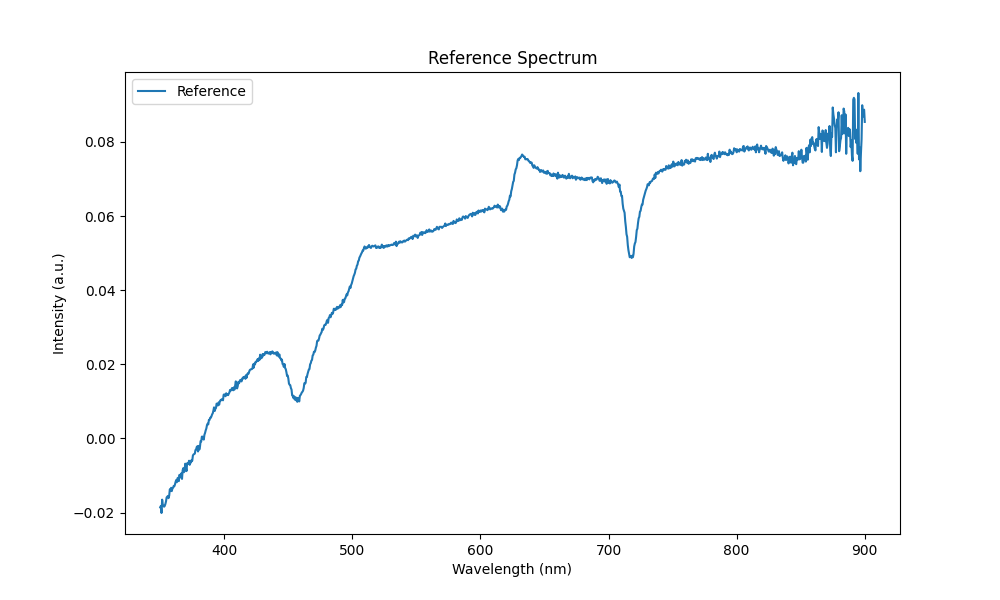

In [4]:
reference_spectrum = np.loadtxt(os.path.join(spettri_dir, "reference2.xy"))

reference_avg = np.mean(reference_spectrum[:, 1])

plt.figure(figsize=(10, 6))
plt.plot(reference_spectrum[:, 0], reference_spectrum[:, 1], label="Reference")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.title("Reference Spectrum")
plt.legend()
plt.show()

In [5]:
file_selector = widgets.Dropdown(
    options=[(sp, sp) for sp in available_spettri],
    description="Select spettri:",
)
display(file_selector)

Dropdown(description='Select spettri:', options=(('reference2.xy', 'reference2.xy'), ('campione_perc_1.xy', 'c…

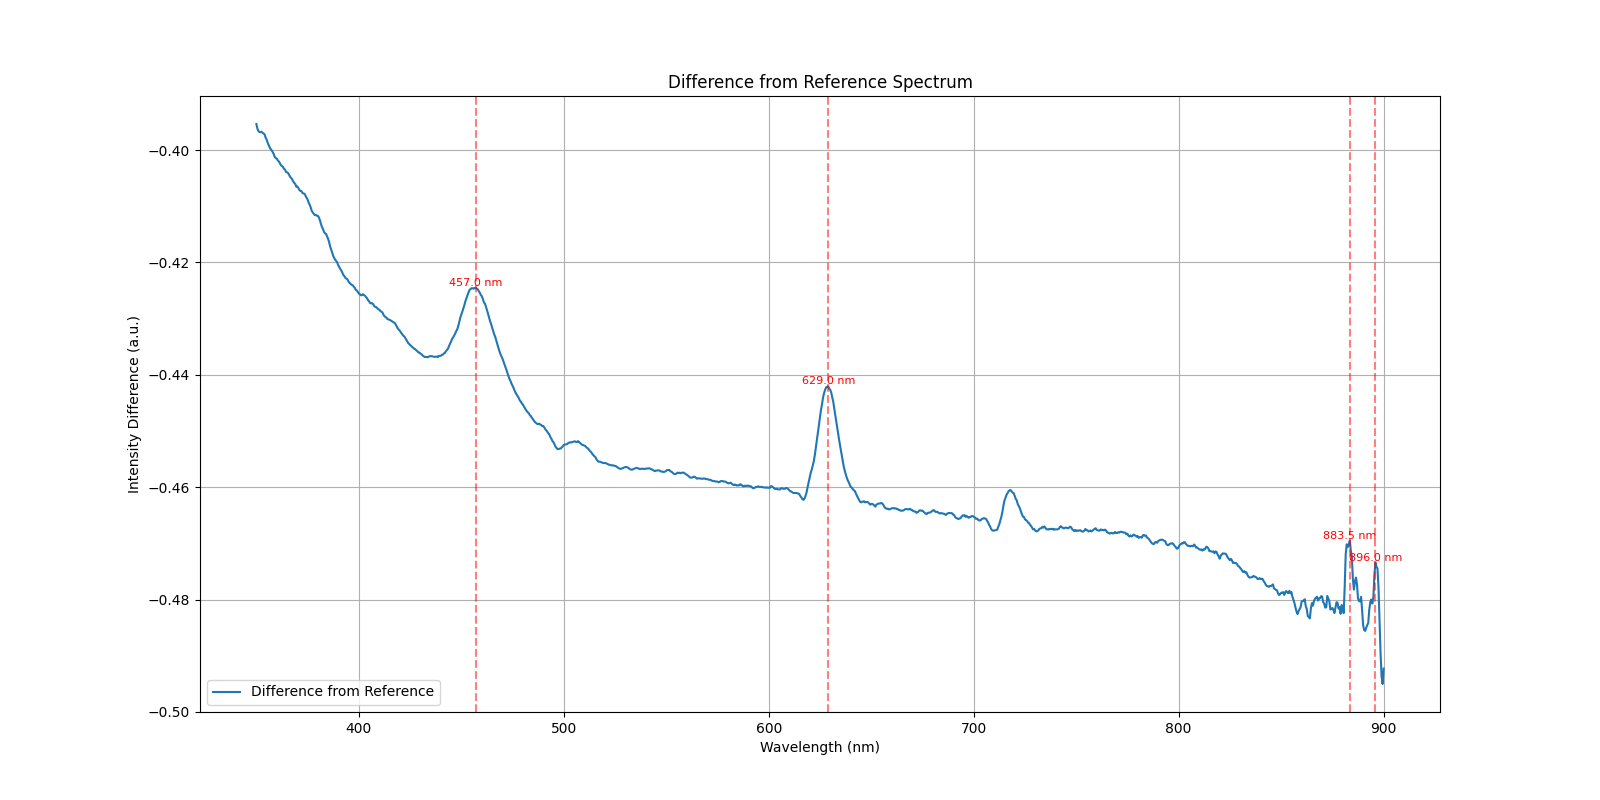

In [8]:
spectrum = np.loadtxt(os.path.join(spettri_dir, file_selector.value))
wavelength = spectrum[:, 0]
intensity = spectrum[:, 1]

diff_from_reference = (intensity - reference_spectrum[:, 1])

diff_from_reference_smooth = sp.signal.savgol_filter(diff_from_reference, window_length=11, polyorder=3)

peaks, _ = sp.signal.find_peaks(diff_from_reference_smooth, prominence=0.01)

plt.figure(figsize=(16, 8))
plt.plot(wavelength, diff_from_reference_smooth, label="Difference from Reference")

#plt.plot(wavelength[peaks], diff_from_reference[peaks], "x", label="Peaks")
#plt.axhline(0, color="gray", linestyle="--", label="Reference Level")
for peak in peaks:
    plt.axvline(wavelength[peak], color="red", linestyle="--", alpha=0.5)
    plt.text(wavelength[peak], diff_from_reference_smooth[peak], f"{wavelength[peak]:.1f} nm", color="red", fontsize=8, ha="center", va="bottom")


plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity Difference (a.u.)")
plt.title("Difference from Reference Spectrum")
plt.legend()
plt.grid()
plt.show()

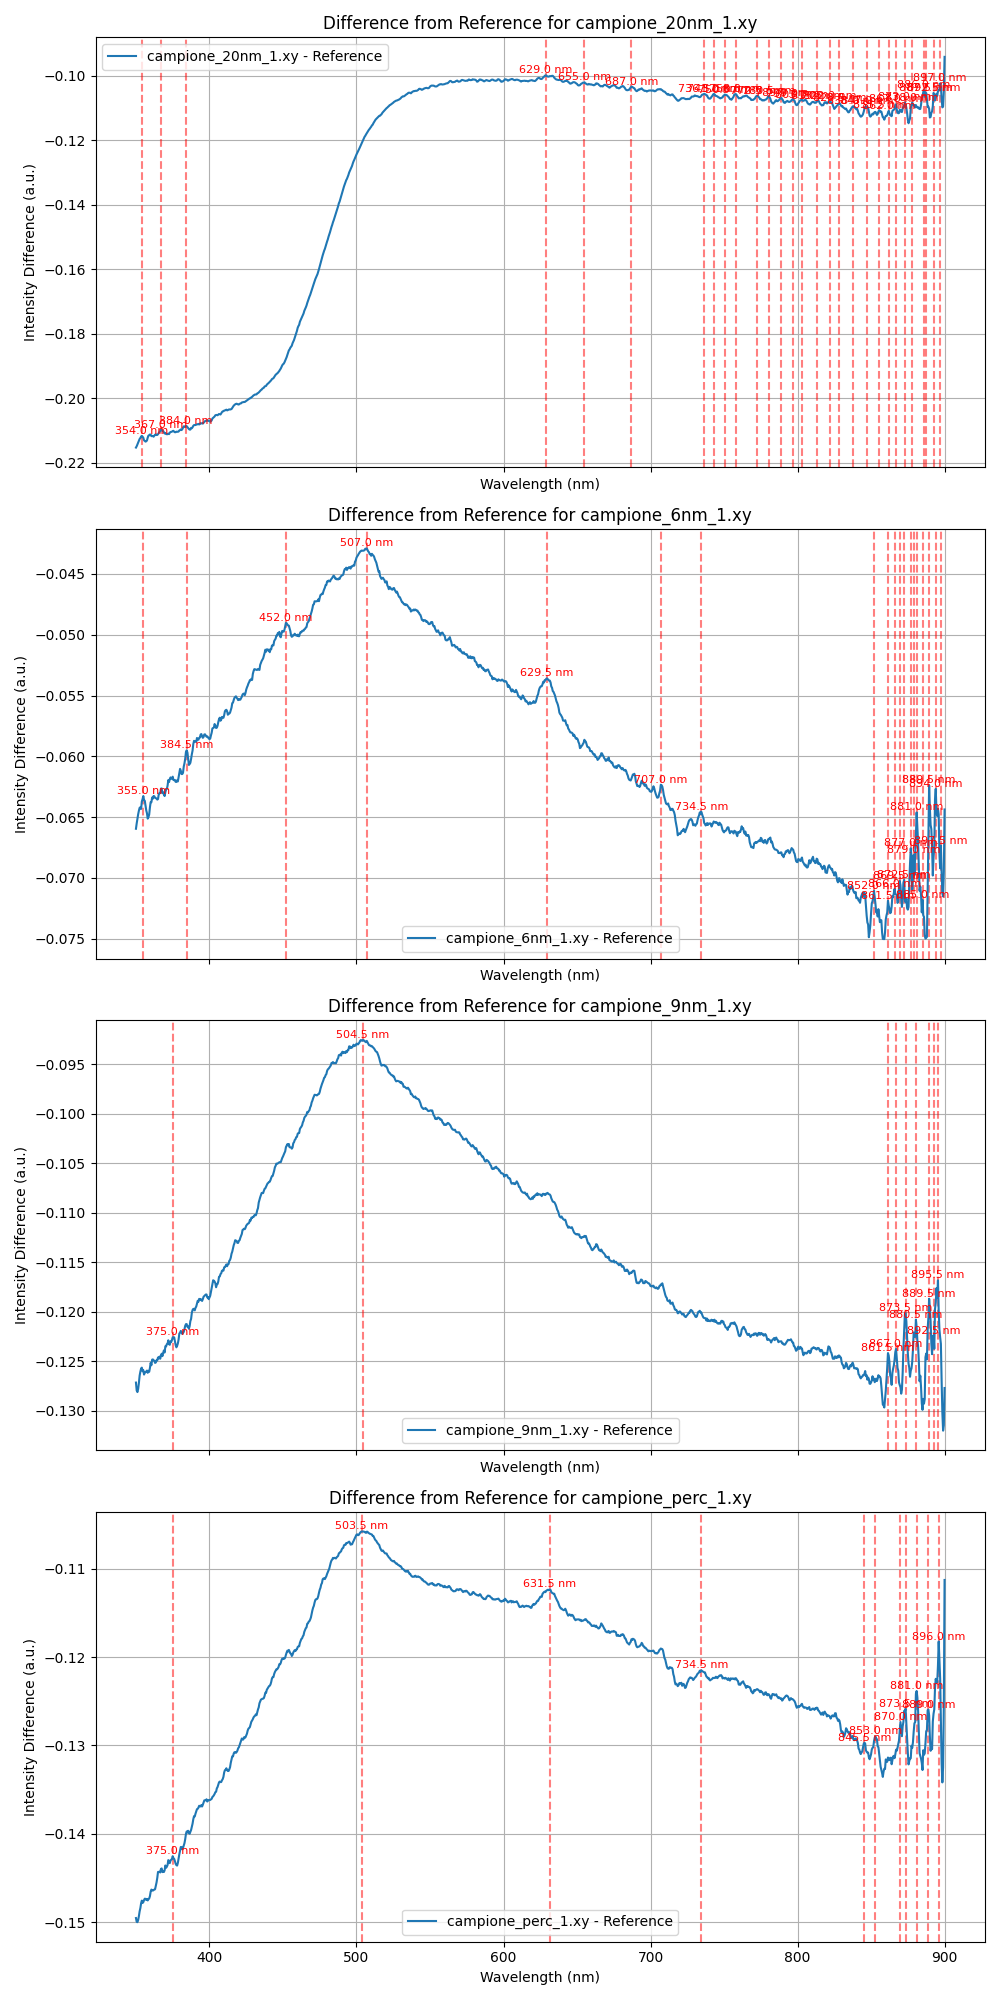

In [12]:
available_spectra = [i for i in os.listdir(spettri_dir) if i.endswith(".xy") and ("perc" in i or "nm" in i)]
available_spectra.sort()

fig, axes = plt.subplots(len(available_spectra), 1, figsize=(10, 5 * len(available_spectra)), sharex=True)

for ax, spectrum_file in zip(axes, available_spectra):
    spectrum = np.loadtxt(os.path.join(spettri_dir, spectrum_file))
    wavelength = spectrum[:, 0]
    intensity = spectrum[:, 1]
    
    diff_from_reference = (intensity - reference_spectrum[:, 1])
    diff_from_reference_smooth = sp.signal.savgol_filter(diff_from_reference, window_length=11, polyorder=3)

    peaks, _ = sp.signal.find_peaks(diff_from_reference_smooth, prominence=0.001)
    for peak in peaks:
        ax.axvline(wavelength[peak], color="red", linestyle="--", alpha=0.5)
        ax.text(wavelength[peak], diff_from_reference_smooth[peak], f"{wavelength[peak]:.1f} nm", color="red", fontsize=8, ha="center", va="bottom")

    
    ax.plot(wavelength, diff_from_reference_smooth, label=f"{spectrum_file} - Reference")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity Difference (a.u.)")
    ax.set_title(f"Difference from Reference for {spectrum_file}")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()
